# CIFAR10 Classification

### HW2 @ DL Course, Dr. Soleymani

*Full Name:* Saeide Danaei

*SID:* 402206907

In this part of the assignment we want to do an image classification task using PyTorch on CIFAR10 dataset.

## Import Libraries

Import needed libraries

In [ ]:
import torch
import torchvision
from torchvision import transforms

## Device

Set device to work with (GPU or CPU)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [ ]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# means = (0.4914, 0.4822, 0.4465)
# stds = (0.2023, 0.1994, 0.2010)
means = (0.5, 0.5, 0.5)
stds = (0.2, 0.2, 0.2)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means,stds)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means,stds)
])

In [ ]:
# inverse the normilize transform to restore the original data
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        # TODO
        img_tensor = tensor.copy()
        for t_id, (m, s) in enumerate(zip(self.mean, self.std)):
            img_tensor[t_id] = img_tensor[t_id] * s + m
        return img_tensor.transpose(1,2,0)


In [ ]:
un = UnNormalize(means,stds)

In [ ]:
initial_trainset = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/Colab Notebooks/DL course/data', train=True,
                                        download=True, transform=transform_train)

100%|██████████| 170498071/170498071 [00:13<00:00, 12859096.69it/s]


Extracting /content/drive/MyDrive/Colab Notebooks/DL course/data/cifar-10-python.tar.gz to /content/drive/MyDrive/Colab Notebooks/DL course/data


In [ ]:
train_size = int(0.8 * len(initial_trainset))
val_size = len(initial_trainset) - train_size
trainset, valset = torch.utils.data.random_split(initial_trainset, [train_size, val_size])


In [ ]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=200, shuffle=False, num_workers=2)

In [ ]:
testset = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/Colab Notebooks/DL course/data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=200, shuffle=False, num_workers=2)

Files already downloaded and verified


## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

In [ ]:
image_samples = [[] for _ in range(len(classes))]
len_check = 0
num_images_per_class = 5
for samples, labels in trainloader:
  if len_check >= len(classes):
    break
  for sample, label in zip(samples, labels):
    if len(image_samples[label]) == num_images_per_class:
      len_check += 1
      continue
    image_samples[label].append(sample)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

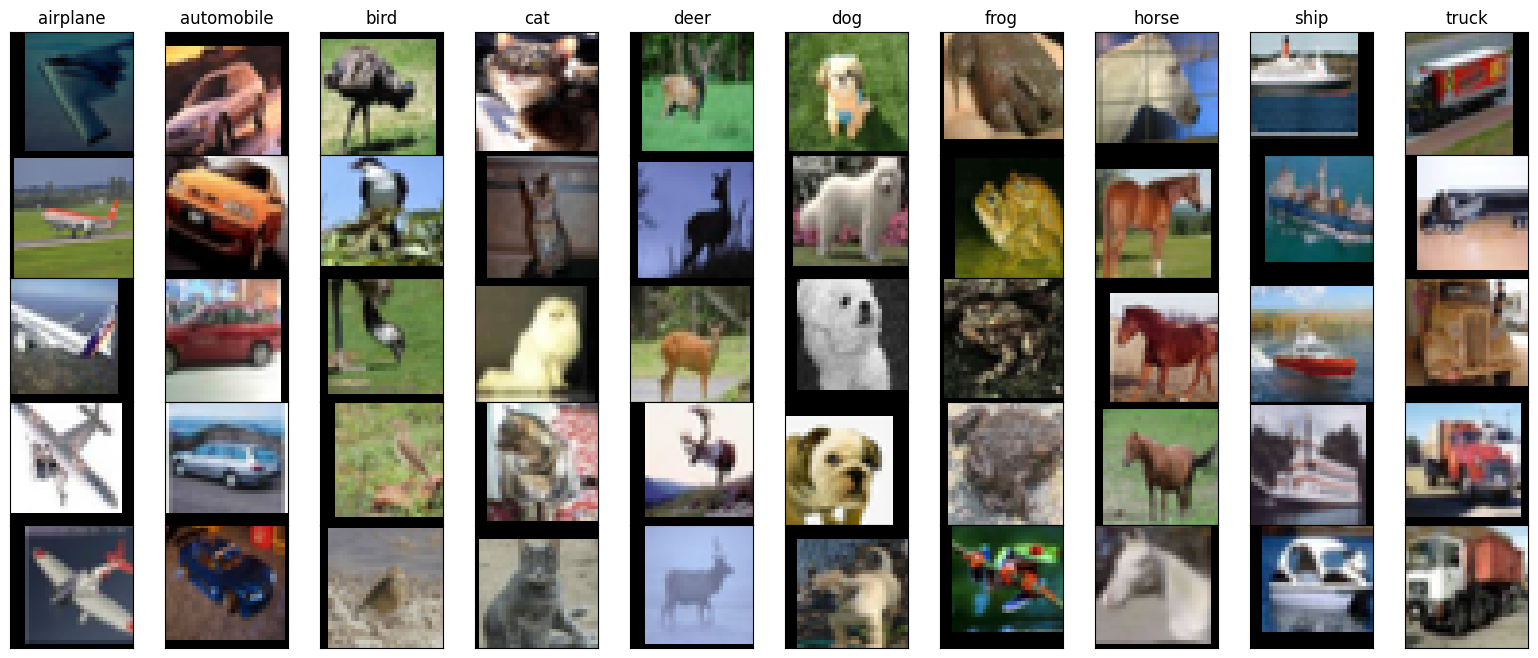

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(num_images_per_class, len(classes), sharex=True, sharey=True, figsize=(20, 8))
# for c_id, c_img in enumerate(image_samples):
for c_id in range(len(classes)):
  for sam_id in range(num_images_per_class):
    # image = norminv(img_samp)  # Unnormalize the image
    image = un(image_samples[c_id][sam_id].numpy())
    # image = c_img[sam_id][0]
    # print(image)
    axes[sam_id,c_id].imshow(image)
    axes[sam_id,c_id].get_xaxis().set_visible(False)
    axes[sam_id,c_id].get_yaxis().set_visible(False)
  axes[0,c_id].set_title(classes[c_id])


plt.subplots_adjust(wspace=0, hspace=0)

## Model

Define your ResNet model here from scratch (You are not allowed to use the existing models in pytorch)

Our suggestion is to implement ResNet18

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the ResNet block
class ResNetBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super(ResNetBlock, self).__init__()
    self.left = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(out_channels)
    )
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels)
        )

  def forward(self, x):
      out = self.left(x)
      out = out + self.shortcut(x)
      out = F.relu(out)

      return out

# Define the ResNet18 model
class ResNet18(nn.Module):
  def __init__(self, num_classes=10):

    super(ResNet18, self).__init__()
    self.inchannel = 64
    self.conv1 = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU()
    )
    self.layer1 = self.make_layer(ResNetBlock, 64, 2, stride=1)
    self.layer2 = self.make_layer(ResNetBlock, 128, 2, stride=2)
    self.layer3 = self.make_layer(ResNetBlock, 256, 2, stride=2)
    self.layer4 = self.make_layer(ResNetBlock, 512, 2, stride=2)
    self.fc = nn.Linear(512, num_classes)

  def make_layer(self, block, channels, num_blocks, stride):
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for stride in strides:
        layers.append(block(self.inchannel, channels, stride))
        self.inchannel = channels
    return nn.Sequential(*layers)

  def pre_final_layers_forward(self, x):
    out = self.conv1(x)
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    out = F.avg_pool2d(out, 4)
    out = out.view(out.size(0), -1)
    return out

  def forward(self, x):
    out = self.pre_final_layers_forward(x)
    out = self.fc(out)
    return out



## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [ ]:
net = ResNet18().to(device)

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01, momentum=0.9)
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, verbose=True)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

### Train loop

Train your model

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage

In [ ]:
import tqdm
from time import time

In [ ]:
from time import time

In [ ]:
def train_epoch(net: torch.nn.Module, criterion: torch.nn.Module, optimizer: torch.optim.Optimizer,scheduler: torch.optim.lr_scheduler ,dataloader: torch.utils.data.DataLoader):
    train_loss = 0.0
    train_accuracy = 0.0
    net.train()
    with tqdm.tqdm(enumerate(trainloader), total=len(trainloader)) as pbar:
      for id, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_loss += loss.item() * len(inputs) / len(trainloader.dataset)
        train_accuracy += ((predicted == labels).squeeze().sum().item()) / len(trainloader.dataset)
        pbar.set_description(f'train: Loss: {train_loss :.4f} - Acc: {train_accuracy*100:.2f}%')

    scheduler.step()

    return train_accuracy, train_loss

def eval_epoch(net: torch.nn.Module, criterion: torch.nn.Module, dataloader: torch.utils.data.DataLoader, test_mode: bool = False):
  accurate = 0.0
  running_loss = 0.0
  net.eval()

  with torch.no_grad(), tqdm.tqdm(enumerate(dataloader), total=len(dataloader)) as pbar:
    for id, (inputs, labels) in pbar:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = net(inputs)
      running_loss += criterion(outputs, labels).item() * len(inputs)
      _, predicted = torch.max(outputs, 1)
      accurate += (predicted == labels).squeeze().sum().item()
      pbar.set_description(f'val: Loss: {running_loss / len(dataloader.dataset) :.4f} - Acc: {(accurate / len(dataloader.dataset))*100:.2f}%')

  valid_accuracy, valid_loss = accurate / len(dataloader.dataset), running_loss / len(dataloader.dataset)

  return valid_accuracy,valid_loss



In [ ]:
epochs = 25
train_accs = []
valid_accs = []
train_losses = []
valid_losses = []

# best_model = None
# best = (0.0, 0.0)
for e in (range(epochs)):
    start_time = time()
    train_acc, train_loss = train_epoch(net, criterion, optimizer, lr_scheduler, trainloader)
    valid_acc, valid_loss = eval_epoch(net, criterion, valloader)
    end_time = time()
    print(f'Epoch {e+1:3} finished in {end_time - start_time:.2f}s')
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)


val: Loss: 1.2419 - Acc: 54.98%: 100%|██████████| 50/50 [00:05<00:00,  9.32it/s]

Epoch   1 finished in 45.64s



val: Loss: 1.0200 - Acc: 64.35%: 100%|██████████| 50/50 [00:04<00:00, 10.31it/s]


Epoch   2 finished in 40.85s


val: Loss: 0.8281 - Acc: 71.82%: 100%|██████████| 50/50 [00:04<00:00, 10.62it/s]

...

Epoch  23 finished in 41.07s


val: Loss: 0.3018 - Acc: 90.59%: 100%|██████████| 50/50 [00:04<00:00, 10.36it/s]

Epoch  24 finished in 40.93s



val: Loss: 0.2944 - Acc: 90.80%: 100%|██████████| 50/50 [00:05<00:00,  8.79it/s]

Epoch  25 finished in 41.80s


### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

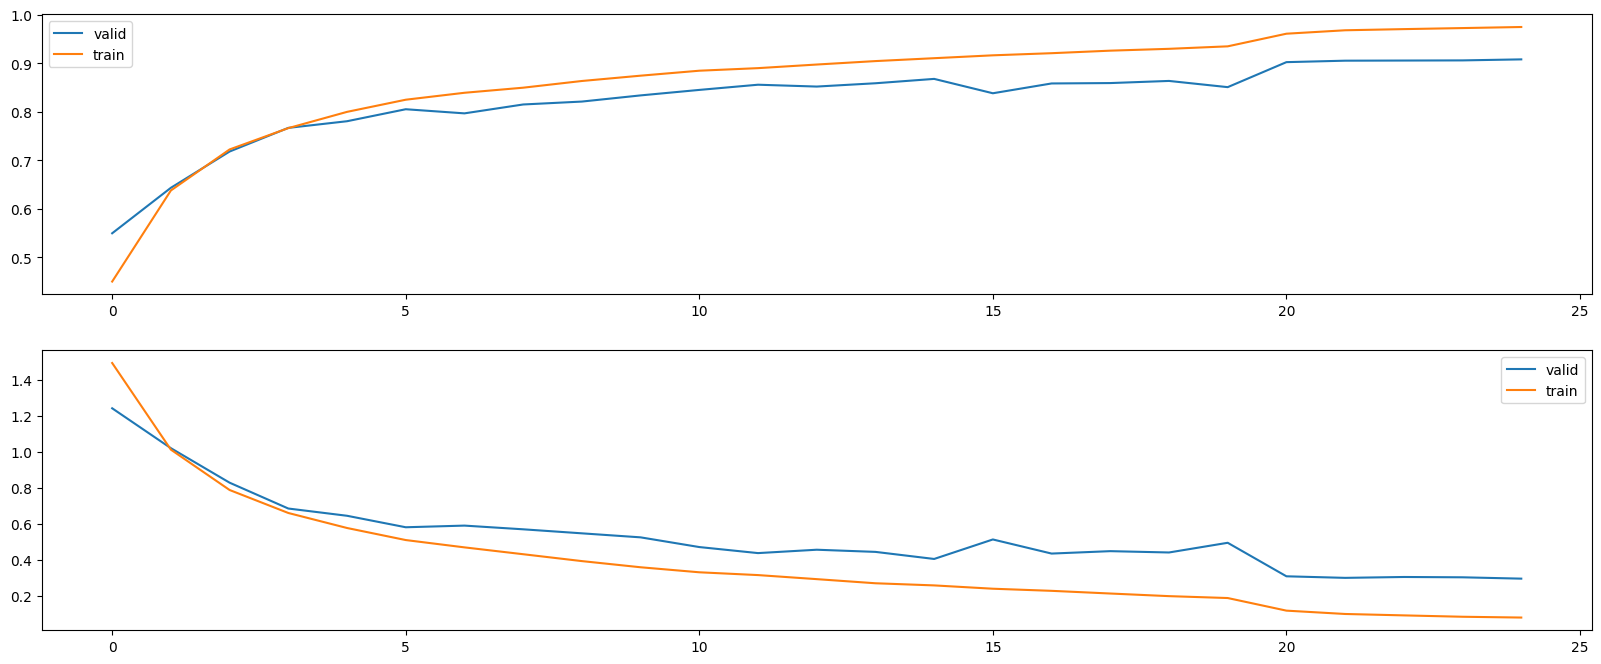

In [ ]:
# TODO
figs, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))
ax1.plot(valid_accs, label='valid')
ax1.plot(train_accs, label='train')
ax1.legend()

ax2.plot(valid_losses, label='valid')
ax2.plot(train_losses, label='train')
ax2.legend()
plt.show()

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `80%`

In [ ]:
valid_acc, valid_loss = eval_epoch(net, criterion, testloader)

val: Loss: 0.3148 - Acc: 91.10%: 100%|██████████| 50/50 [00:04<00:00, 11.38it/s]


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model

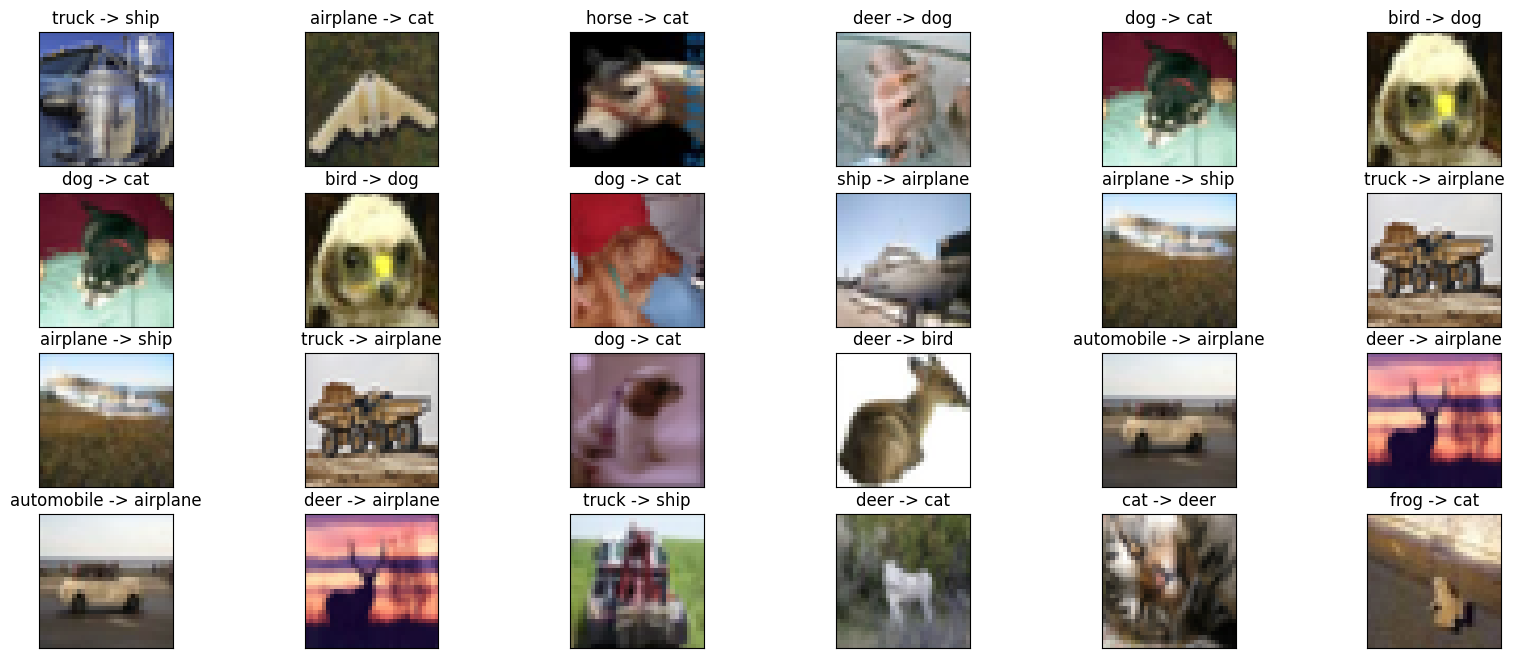

In [ ]:
# TODO
wrongs = []
with torch.no_grad():
  for (inputs, labels) in testloader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = net(inputs)
    _, predicted = torch.max(outputs, 1)
    for predict, label, inp in zip(predicted, labels, inputs):
      if predict != label:
        wrongs.append((inp, label, predict))

    if len(wrongs) >= 24:
      break

figs, axs = plt.subplots(4, 6, figsize=(20, 8), sharex=True, sharey=True)

for i in range(4):
  for j in range(6):
    img, label, predict = wrongs[i * 4 + j]
    axs[i, j].imshow(un(img.cpu().numpy()))
    axs[i, j].set_title(f'{classes[label]} -> {classes[predict]}')
    axs[i, j].get_xaxis().set_visible(False)
    axs[i, j].get_yaxis().set_visible(False)

## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(50000, N)` saved in a variable (for later usage)

- **Hint 1:** define a tensor with dimension `(50000, N)` where *50000* is the size of the trainset and *N* is the dimension of the feature space

- **Hint 2:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [ ]:
# TODO
inittrainsetloader = torch.utils.data.DataLoader(initial_trainset, batch_size=200, shuffle=False)
all_labels = []
all_inputs = []

outputs = []
with torch.no_grad():
    for (inputs, labels) in inittrainsetloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs.extend(net.pre_final_layers_forward(inputs))
        all_labels.extend(labels)
        all_inputs.extend(inputs)

outputs = torch.stack(outputs)
all_labels = torch.stack(all_labels)
all_inputs = torch.stack(all_inputs)

### K Nearest Neighbor in feature space

You already have calculated the feature spaces for trainset ($S$) in the previous section

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them


**Hint:** For finding the nearest neighbors in the feature space you can use `torch.linalg.norm` and `torch.topk`

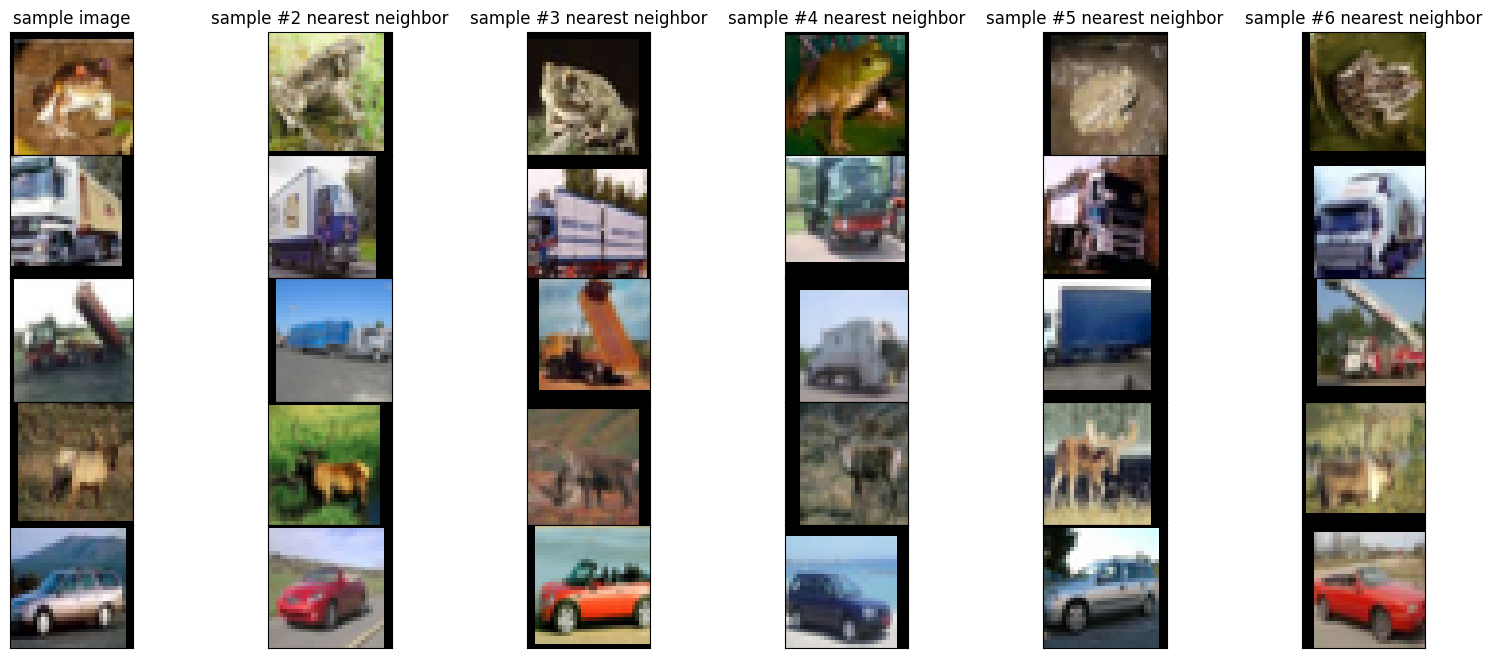

In [ ]:
# TODO

figs, axs = plt.subplots(5, 6, sharex=True, sharey=True, figsize=(20, 8))
axs[0, 0].set_title('sample image')

for i in range(1, 6):
    axs[0, i].set_title(f'sample #{i + 1} nearest neighbor')

with torch.no_grad():
  _, predicted = torch.max(net.fc(outputs), 1)
  count = 0
  for predict, label, inp, out in zip(predicted, all_labels, all_inputs, outputs):
    if predict == label:
      _, similar_indices = torch.topk(torch.linalg.norm(outputs - out, dim=1), k=6, largest=False)
      for i, sim_img in enumerate(all_inputs[similar_indices]):
          img = un(sim_img.cpu().numpy())
          axs[count, i].imshow(img)
          axs[count, i].get_xaxis().set_visible(False)
          axs[count, i].get_yaxis().set_visible(False)
      count += 1
    if count == 5:
        break

plt.subplots_adjust(wspace=0, hspace=0)

### TSNE

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now you have a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)
4. Visualize the points in a 2D plane (Set color of each point based on it's class)

**Hint:** You can use `sklearn.manifold.TSNE`

**Hint:** Use `plt.scatter(x, y, c=labels)`


In [ ]:
from sklearn.manifold import TSNE

In [ ]:
# TODO
indices = torch.randperm(outputs.size(0))[:2000]
X = outputs[indices].to('cpu').numpy()
y = all_labels[indices].to('cpu').numpy()
reduced_X = TSNE(2).fit_transform(X)
reduced_X.shape



(2000, 2)

<Axes: xlabel='x', ylabel='y'>

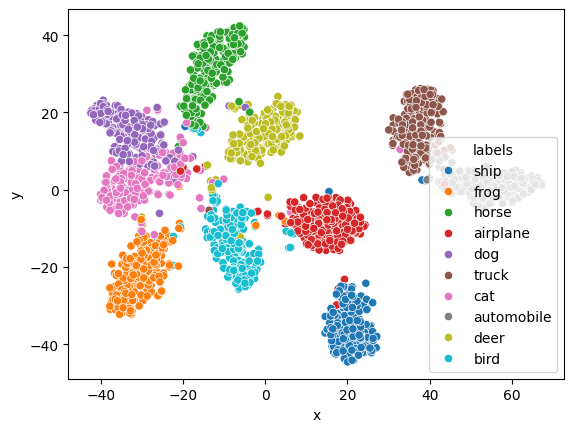

In [ ]:
import pandas as pd
import seaborn as sns
labels=[classes[t] for t in y]
plot_data = pd.DataFrame({'x':reduced_X[:,0],'y':reduced_X[:,1],'labels':labels})
sns.scatterplot(data=plot_data, x='x', y='y', hue='labels')

# CIFAR10 Colorization

In this part of the assignment, we want to do an image colorization task using PyTorch on CIFAR10 dataset. We want to train a model that colors  a black-and-white image.

## Import Libraries

Import needed libraries

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Custom Dataset

Define a custom dataset class by extensing `torch.utils.data.Dataset`

**Notice:** your dataset should output two things: black-and-white image and the RGB image

**Hint:** You don't have to reinvent the wheel. Your class should just be a wrapper for CIFAR10 dataset

In [ ]:
class BlackAndWhiteCIFAR10(Dataset):
    """
    Define a custom dataset class by extending `torch.utils.data.Dataset`
    this class is a dataset for the CIFAR10 data in pytorch and it has the black and white image of the original CIFAR10 image as the data
    and the original RGB image as the target
    this class is just a wrapper for the torchvision.datasets.CIFAR10 class
    """

    def __init__(self, train=True, root='./data', download=True, transform=None):
        self.cifar_dataset = torchvision.datasets.CIFAR10(root=root, download=download, train=train, transform=transform)
        self.n_samples = len(self.cifar_dataset)
        self.transform = transforms.Grayscale()

    def __len__(self):
        return self.n_samples

    def __getitem__(self, index):
      rgb_image, label = self.cifar_dataset[index]
      bw_image = self.transform(rgb_image)
      return bw_image, rgb_image

## Transforms & Dataset & Dataloader

**Notice:** Use your defined custom dataset class for defining the datasets

In [ ]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
batch_size = 256
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
initial_trainset = BlackAndWhiteCIFAR10(root='/content/drive/MyDrive/Colab Notebooks/DL course/data', train=True,
                                        download=True, transform=transform_train)

100%|██████████| 170498071/170498071 [00:17<00:00, 9907292.01it/s] 


Extracting /content/drive/MyDrive/Colab Notebooks/DL course/data/cifar-10-python.tar.gz to /content/drive/MyDrive/Colab Notebooks/DL course/data


In [ ]:
train_size = int(0.8 * len(initial_trainset))
val_size = len(initial_trainset) - train_size
trainset, valset = torch.utils.data.random_split(initial_trainset, [train_size, val_size])


In [ ]:
trainloader = torch.utils.data.DataLoader(trainset, shuffle=True, num_workers=2, batch_size=batch_size)
valloader = torch.utils.data.DataLoader(valset, shuffle=False, num_workers=2, batch_size=batch_size)

## Dataset Visualization

Visualize your dataset (black-and-white image along with the RGB image) by sampling from your trainset

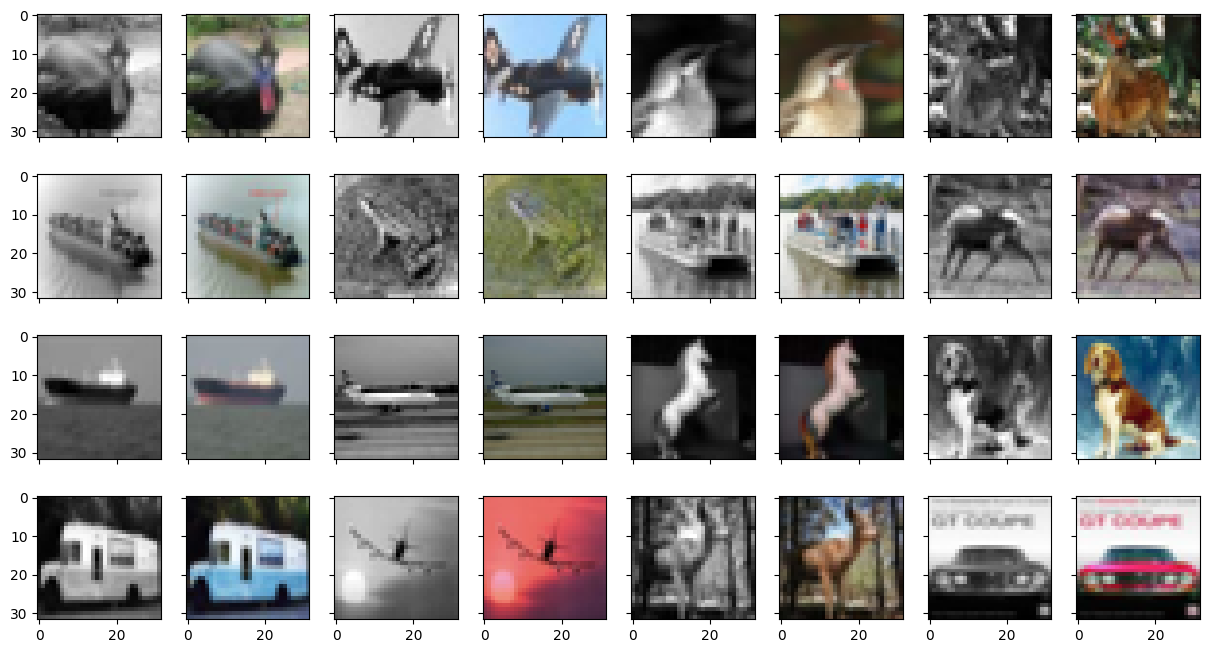

In [ ]:
# TODO
fig, axs = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(15, 8))
img_iterator = iter(trainset)
for i in range(16):
  img_bw, img_rgb = next(img_iterator)
  r, c = i // 4, 2 * (i % 4)
  axs[r, c].imshow(img_bw.permute(1,2,0), cmap='gray')
  axs[r, c + 1].imshow(img_rgb.permute(1, 2, 0))

## Model

Define your model here (Input: black-and-white image, Output: RGB image)

**Hint:** You can implement an autoencoder that does the colorization task for you. UNet could be a viable option

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class TransConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransConvBlock, self).__init__()
        self.transconv = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip_input):
        x = self.transconv(x)
        pad_y, pad_x = skip_input.size()[2] - x.size()[2], skip_input.size()[3] - x.size()[3]
        x = F.pad(x, (pad_x // 2, (pad_x + 1) // 2, pad_y // 2, (pad_y + 1) // 2))
        # Concatenate skip connection
        x = torch.cat([skip_input, x], dim=1)
        x = self.conv(x)
        return x


class ColorizationUNet(nn.Module):
  def __init__(self):
    super(ColorizationUNet, self).__init__()
    self.first_conv = ConvBlock(1, 64)
    self.down1 = ConvBlock(64, 128)
    self.down2 = ConvBlock(128, 256)
    self.down3 = ConvBlock(256, 512)
    self.down4 = ConvBlock(512, 512)

    self.up1 = TransConvBlock(1024, 256)
    self.up2 = TransConvBlock(512, 128)
    self.up3 = TransConvBlock(256, 64)
    self.up4 = TransConvBlock(128, 64)
    self.final_conv = nn.Conv2d(64, 3, kernel_size=1)

  def forward(self, x):
    # Encoder
    x1 = self.first_conv(x)
    x2 = nn.functional.max_pool2d(x1, 2)
    x3 = self.down1(x2)
    x4 = nn.functional.max_pool2d(x3, 2)
    x5 = self.down2(x4)
    x6 = nn.functional.max_pool2d(x5, 2)
    x7 = self.down3(x6)
    x8 = nn.functional.max_pool2d(x7, 2)
    x9 = self.down4(x8)

    # Decoder
    x10 = self.up1(x9, x7)
    x11 = self.up2(x10, x5)
    x12 = self.up3(x11, x3)
    x13 = self.up4(x12, x1)
    output = self.final_conv(x13)
    return output


## Train

Train your model

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Validation loss
- [ ] save train/validation loss (of each epoch) in an array for later usage

In [ ]:
net = ColorizationUNet().to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
import tqdm
from time import time

In [ ]:
def train_epoch(net: nn.Module, criterion: nn.Module, optimizer: torch.optim.Optimizer, dataloader: torch.utils.data.DataLoader):
    net.train()
    running_loss = 0.0

    with tqdm.tqdm(enumerate(dataloader), total=len(dataloader)) as pbar:
      for id, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(dataloader.dataset)
      # pbar.set_description(f'train: Loss: {epoch_loss :.4f} ')
    return epoch_loss

def eval_epoch(net: nn.Module, criterion: nn.Module, dataloader: torch.utils.data.DataLoader, test_mode: bool = False):
    net.eval()
    running_loss = 0.0
    with torch.no_grad(), tqdm.tqdm(enumerate(dataloader), total=len(dataloader)) as pbar:
      for id, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
      epoch_loss = running_loss / len(dataloader.dataset)
      # pbar.set_description(f'val: Loss: {epoch_loss :.4f} ')


    return epoch_loss


In [ ]:
epochs = 15
train_losses = []
valid_losses = []

for e in range(epochs):
  start_time = time()
  train_loss = train_epoch(net, criterion, optimizer, trainloader)
  valid_loss = eval_epoch(net, criterion, valloader)
  end_time = time()
  train_losses.append(train_loss)
  valid_losses.append(valid_loss)
  print(f"Epoch {e+1} finished in {end_time - start_time:.2f}s ---> train loss: {train_loss:.4f}, validation loss: {valid_loss:.4f}")


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
 99%|█████████▉| 156/157 [00:34<00:00,  4.49it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 40/40 [00:04<00:00,  8.05it/s]

Epoch 1 finished in 39.91s ---> train loss: 0.0070, validation loss: 0.0067



100%|██████████| 40/40 [00:04<00:00,  8.16it/s]

Epoch 2 finished in 40.59s ---> train loss: 0.0064, validation loss: 0.0065



100%|██████████| 40/40 [00:04<00:00,  8.04it/s]

...

Epoch 13 finished in 41.24s ---> train loss: 0.0053, validation loss: 0.0053



100%|██████████| 40/40 [00:04<00:00,  8.17it/s]

Epoch 14 finished in 40.82s ---> train loss: 0.0051, validation loss: 0.0056



100%|██████████| 40/40 [00:04<00:00,  8.09it/s]

Epoch 15 finished in 40.89s ---> train loss: 0.0052, validation loss: 0.0055


### Visualize Loss plot

Using the arrays that you have (from task 2 in the above section), visualize the loss plot (train and validation together)

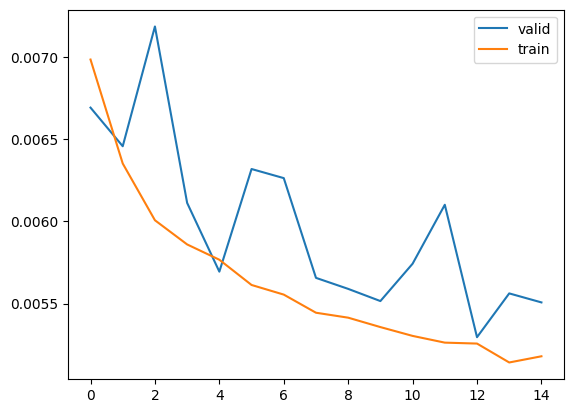

In [ ]:
# TODO
plt.plot(valid_losses, label='valid')
plt.plot(train_losses, label='train')
plt.legend()

## Evaluation

1. Sample 36 random samples from testset (your own dataset class)
2. Give each of the 36 samples to your trained model and get the outputs
3. Visualize `input` (black-and-white image), `output` (output of the model with the given black-and-white input image) and `ground truth` (the actual RGB image)



In [ ]:
testset = BlackAndWhiteCIFAR10(root='/content/drive/MyDrive/Colab Notebooks/DL course/data', train=False,
                                        download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Files already downloaded and verified


In [ ]:
import warnings
warnings.filterwarnings("ignore")

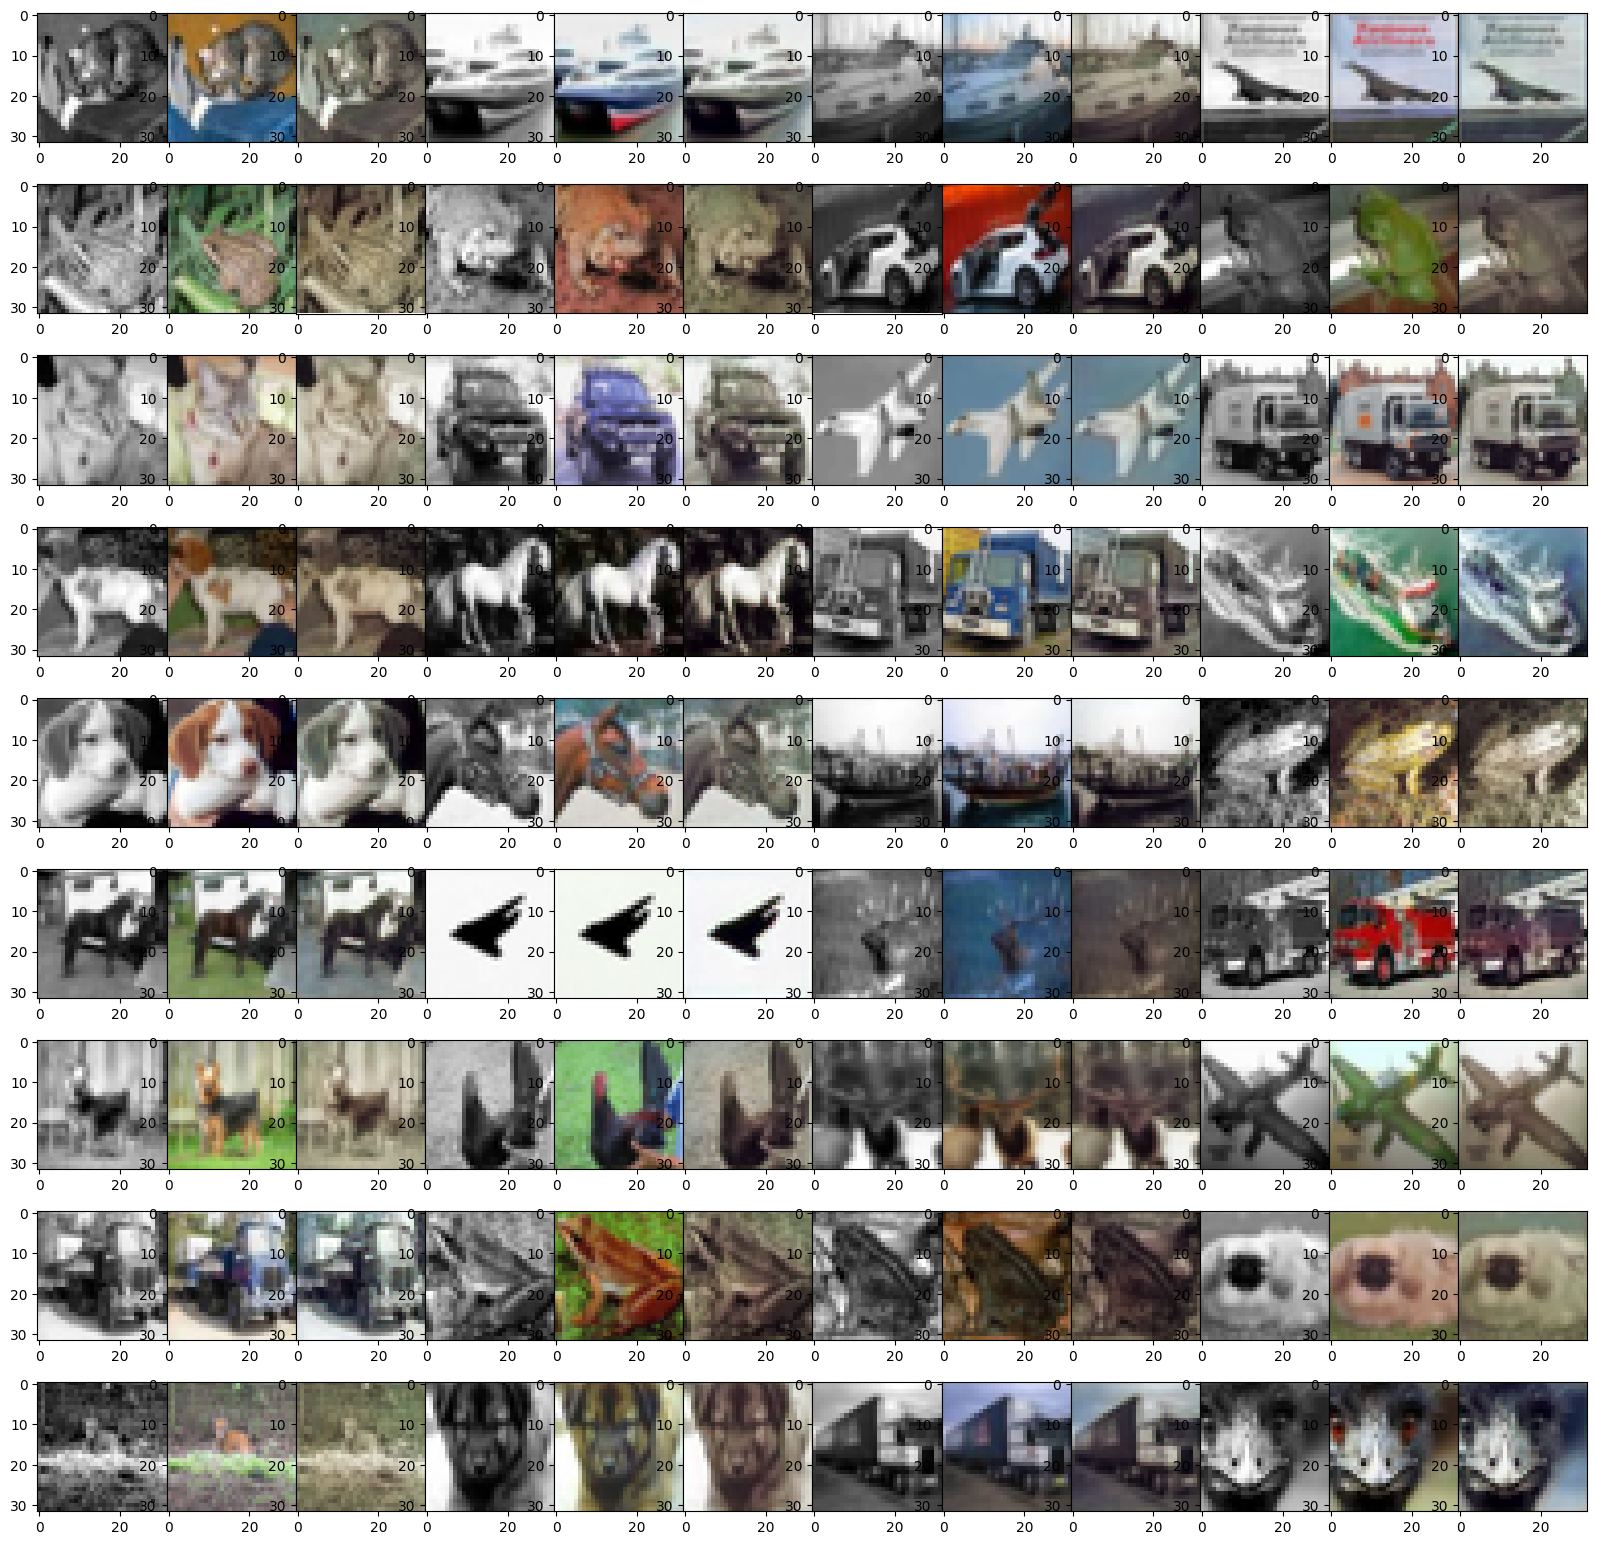

In [ ]:
# TODO
_, axs = plt.subplots(9, 12, figsize=(20, 20))

data = next(iter(testloader))
inputs, labels = data[0].to(device), data[1].to(device)
with torch.no_grad():
  outputs = net(inputs)

for i in range(36):
  bw = inputs[i]
  rgb = labels[i]
  predict = outputs[i]
  x, y = (i // 4), 3 * (i % 4)
  axs[x, y].imshow(bw.cpu().numpy()[0], cmap='gray')
  axs[x, y + 1].imshow(rgb.cpu().numpy().transpose(1, 2, 0))
  axs[x, y + 2].imshow(predict.cpu().numpy().transpose(1, 2, 0))

plt.subplots_adjust(wspace=0, hspace=0)